# 🎬 01 — Exploratory Data Analysis
This notebook loads the Netflix Prize dataset sample (5,000,000 ratings) and generates key summary statistics and visualizations covering rating distributions, user activity, movie popularity, and temporal trends.

In [1]:
import sys
import os
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent))
from src.data_pipeline import load_all_data, load_movie_titles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Load dataset and titles
df = load_all_data(sample_size=5_000_000)
movies = load_movie_titles()
df_merged = df.merge(movies, on='movie_id', how='left')

print("Sampled data shape:", df.shape)
print("Merge data shape:", df_merged.shape)
print(df_merged.head())

Loading from cached parquet: D:\project_4th_year\cult_summer_project\netflix-recommendation-system\data\processed\ratings_sample.parquet


Loading movie titles from: D:\project_4th_year\cult_summer_project\netflix-recommendation-system\data\raw\movie_titles.csv


Sampled data shape: (4999999, 4)
Merge data shape: (4999999, 6)
   movie_id  user_id  rating       date    year                title
0      5571   992739       4 2003-08-31  1976.0                Rocky
1       175  1060026       5 2004-09-25  1992.0       Reservoir Dogs
2     15410  2518672       3 2005-09-20  2002.0  The Dancer Upstairs
3     16325  2430662       5 2004-07-27  1968.0   Planet of the Apes
4      6054  1494270       2 2005-10-08  1954.0    Conquest of Space


## 2.2 Dataset Summary Stats

In [2]:
total_ratings = len(df)
unique_users = df['user_id'].nunique()
unique_movies = df['movie_id'].nunique()
min_date = df['date'].min()
max_date = df['date'].max()
mean_rating = df['rating'].mean()
median_rating = df['rating'].median()
std_rating = df['rating'].std()
sparsity = 1 - (total_ratings / (unique_users * unique_movies))

stats = pd.DataFrame({
    'Metric': ['Total Ratings', 'Unique Users', 'Unique Movies', 'Date Range Start', 'Date Range End', 'Mean Rating', 'Median Rating', 'Std Deviation', 'Sparsity'],
    'Value': [total_ratings, unique_users, unique_movies, str(min_date.date()), str(max_date.date()), f"{mean_rating:.4f}", int(median_rating), f"{std_rating:.4f}", f"{sparsity*100:.4f}%"]
})
print(stats.to_string(index=False))

          Metric      Value
   Total Ratings    4999999
    Unique Users     427949
   Unique Movies      17735
Date Range Start 1999-11-11
  Date Range End 2005-12-31
     Mean Rating     3.6043
   Median Rating          4
   Std Deviation     1.0852
        Sparsity   99.9341%


## 2.3 Rating Distribution Plot

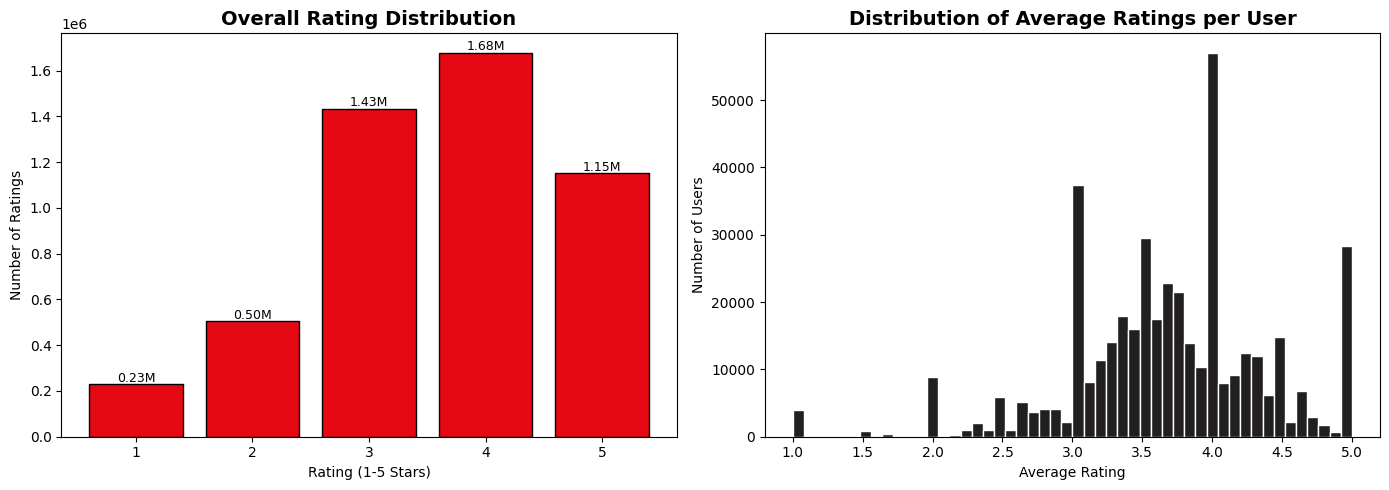

In [3]:
os.makedirs('../reports/figures/', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='#E50914', edgecolor='black')
axes[0].set_title('Overall Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating (1-5 Stars)')
axes[0].set_ylabel('Number of Ratings')
for i, v in enumerate(rating_counts.values):
    axes[0].text(i+1, v + 10000, f'{v/1e6:.2f}M', ha='center', fontsize=9)

# Average rating per user (distribution)
user_avg = df.groupby('user_id')['rating'].mean()
axes[1].hist(user_avg, bins=50, color='#221F1F', edgecolor='white')
axes[1].set_title('Distribution of Average Ratings per User', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.savefig('../reports/figures/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 User Activity Analysis

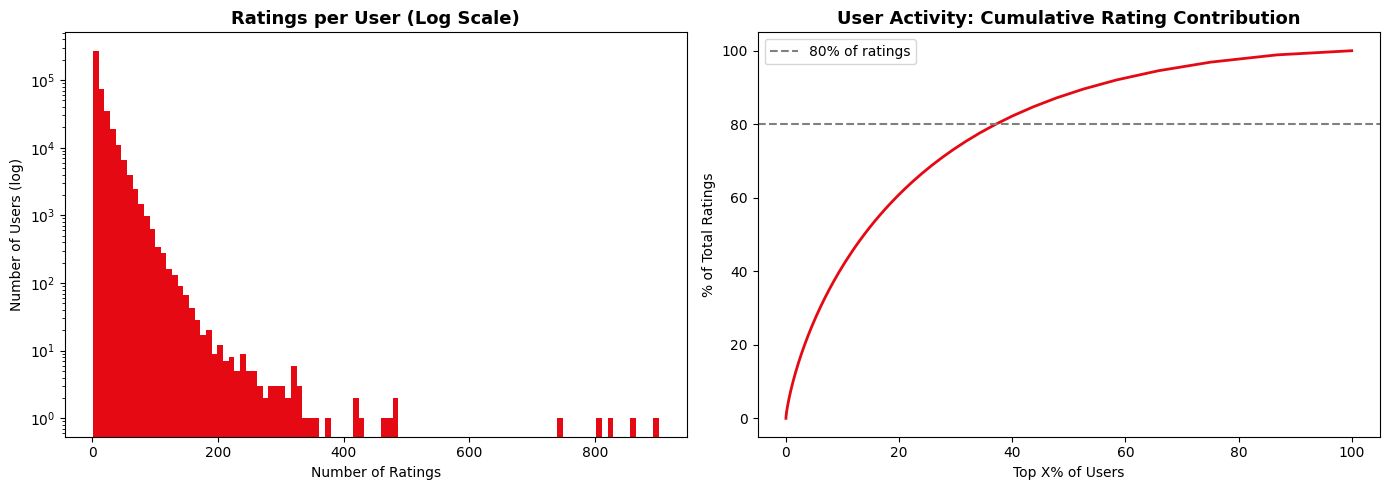

Top 10% of users contribute: 41.4% of ratings
Users with < 5 ratings: 179,446 (41.9%)


In [4]:
ratings_per_user = df.groupby('user_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ratings_per_user, bins=100, color='#E50914', log=True)
axes[0].set_title('Ratings per User (Log Scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users (log)')

# Cumulative: what % of users contribute X% of ratings
sorted_counts = ratings_per_user.sort_values(ascending=False)
cumulative = sorted_counts.cumsum() / sorted_counts.sum() * 100
user_percentile = np.arange(1, len(sorted_counts)+1) / len(sorted_counts) * 100
axes[1].plot(user_percentile, cumulative, color='#E50914', linewidth=2)
axes[1].axhline(80, color='gray', linestyle='--', label='80% of ratings')
axes[1].set_title('User Activity: Cumulative Rating Contribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Top X% of Users')
axes[1].set_ylabel('% of Total Ratings')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/user_activity.png', dpi=150, bbox_inches='tight')
plt.show()

top_10_contrib = cumulative.iloc[int(len(cumulative)*0.1)]
users_lt5 = (ratings_per_user < 5).sum()
users_lt5_pct = (ratings_per_user < 5).mean() * 100
print(f"Top 10% of users contribute: {top_10_contrib:.1f}% of ratings")
print(f"Users with < 5 ratings: {users_lt5:,} ({users_lt5_pct:.1f}%)")

## 2.5 Movie Popularity Trends

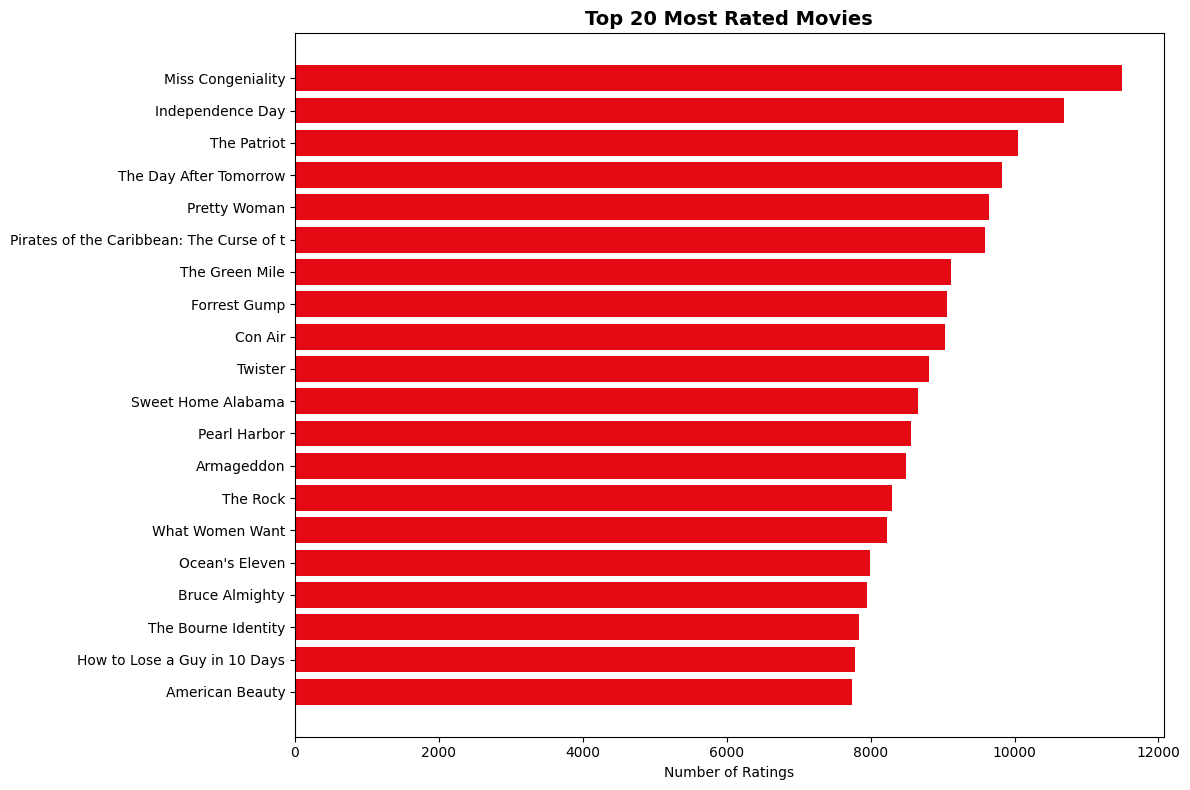

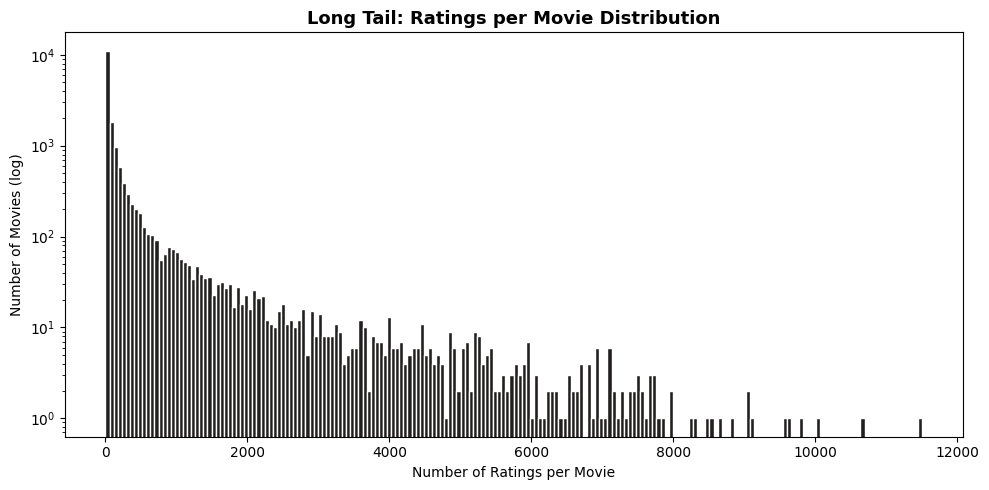

Movies with fewer than 100 ratings: 70.5%


In [5]:
ratings_per_movie = df.groupby('movie_id').size().reset_index(name='rating_count')
top_movies = ratings_per_movie.nlargest(20, 'rating_count').merge(movies, on='movie_id')

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_movies['title'].str[:40], top_movies['rating_count'], color='#E50914')
ax.set_title('Top 20 Most Rated Movies', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Ratings')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/top_movies.png', dpi=150, bbox_inches='tight')
plt.show()

# Long tail: distribution of ratings per movie
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ratings_per_movie['rating_count'], bins=200, log=True, color='#221F1F', edgecolor='white')
ax.set_title('Long Tail: Ratings per Movie Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Ratings per Movie')
ax.set_ylabel('Number of Movies (log)')
plt.tight_layout()
plt.savefig('../reports/figures/long_tail.png', dpi=150, bbox_inches='tight')
plt.show()

pct_under_100 = (ratings_per_movie['rating_count'] < 100).mean() * 100
print(f"Movies with fewer than 100 ratings: {pct_under_100:.1f}%")

## 2.6 Temporal Analysis

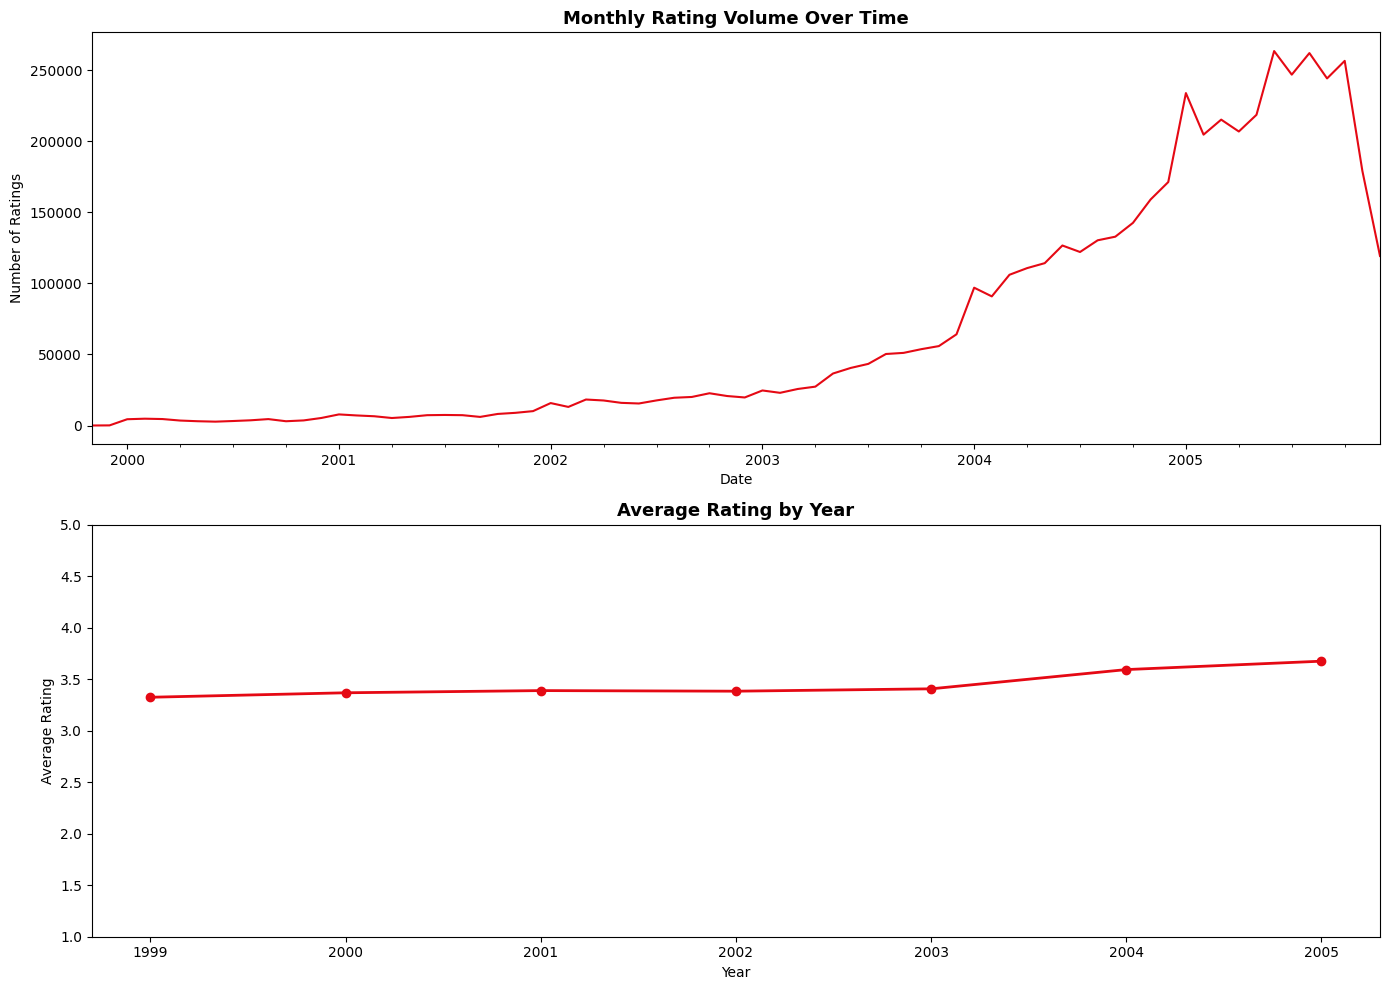

In [6]:
df['year_month'] = df['date'].dt.to_period('M')
monthly = df.groupby('year_month').size()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

monthly.plot(ax=axes[0], color='#E50914', linewidth=1.5)
axes[0].set_title('Monthly Rating Volume Over Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Ratings')

df['year_rated'] = df['date'].dt.year
yearly_avg = df.groupby('year_rated')['rating'].mean()
yearly_avg.plot(ax=axes[1], marker='o', color='#E50914', linewidth=2)
axes[1].set_title('Average Rating by Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.savefig('../reports/figures/temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.7 Sparsity Visualization

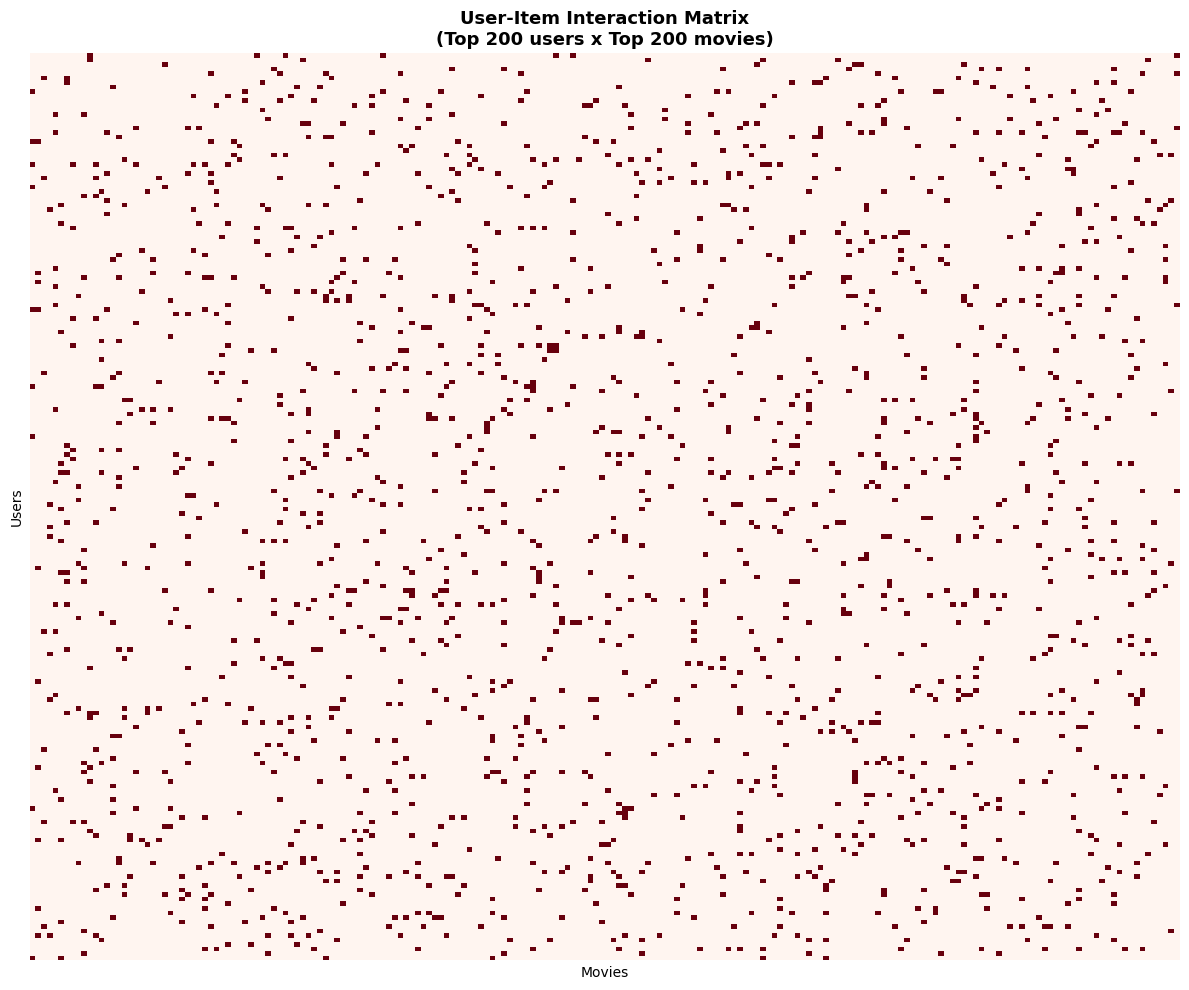

In [7]:
n_sample_users = 200
n_sample_movies = 200

sample_users = df['user_id'].value_counts().head(n_sample_users).index
sample_movies = df['movie_id'].value_counts().head(n_sample_movies).index

matrix_sample = df[
    df['user_id'].isin(sample_users) & df['movie_id'].isin(sample_movies)
].pivot_table(index='user_id', columns='movie_id', values='rating')

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(matrix_sample.notna(), cmap='Reds', cbar=False, ax=ax,
            xticklabels=False, yticklabels=False)
ax.set_title(f'User-Item Interaction Matrix\n(Top {n_sample_users} users x Top {n_sample_movies} movies)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Movies')
ax.set_ylabel('Users')
plt.tight_layout()
plt.savefig('../reports/figures/sparsity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.8 Save EDA Insights to JSON

In [8]:
os.makedirs('../reports/results/', exist_ok=True)
eda_insights = {
    "total_ratings_sampled": len(df),
    "unique_users": int(df['user_id'].nunique()),
    "unique_movies": int(df['movie_id'].nunique()),
    "sparsity_pct": float(round(sparsity * 100, 4)),
    "mean_rating": float(round(df['rating'].mean(), 4)),
    "median_rating": float(df['rating'].median()),
    "std_rating": float(round(df['rating'].std(), 4)),
    "date_range_start": str(df['date'].min()),
    "date_range_end": str(df['date'].max()),
    "users_with_lt5_ratings_pct": float(round(users_lt5_pct, 2)),
    "movies_with_lt100_ratings_pct": float(round(pct_under_100, 2)),
}

with open('../reports/results/eda_insights.json', 'w') as f:
    json.dump(eda_insights, f, indent=2)

print(json.dumps(eda_insights, indent=2))

{
  "total_ratings_sampled": 4999999,
  "unique_users": 427949,
  "unique_movies": 17735,
  "sparsity_pct": 99.9341,
  "mean_rating": 3.6043,
  "median_rating": 4.0,
  "std_rating": 1.0852,
  "date_range_start": "1999-11-11 00:00:00",
  "date_range_end": "2005-12-31 00:00:00",
  "users_with_lt5_ratings_pct": 41.93,
  "movies_with_lt100_ratings_pct": 70.49
}
